In [1]:
import argparse
import torch
from torch import nn, Tensor, optim
from typing import Optional, Union, Tuple, List, Any
import torch.optim as optim
from torch.ao.quantization import QuantStub, DeQuantStub
from torch.nn.quantized import FloatFunctional


import os
import json
import random
import numpy as np
from torch.utils.data import Dataset, DataLoader, RandomSampler
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
from pycocotools.coco import COCO
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode
import matplotlib.pyplot as plt
import torchvision.transforms as T
import torch.nn.functional as F 
import math


from cv_nets.utils.config_helper import get_param
from cv_nets.layers.activation import build_activation_layer
from cv_nets.layers.normalization import build_normalization_layer
from cv_nets.layers.pooling import build_pooling_layer
from cv_nets.layers import *

In [2]:
IMAGE_SIZE = (320, 320)
BATCH_SIZE = 16
NUM_WORKERS = 16
EPOCH = 30
accumulation_steps = 16

TRAIN_IMG_DIR = './data/COCO/train2017'
TRAIN_ANN_FILE = './data/COCO/annotations/instances_train2017.json'

VAL_IMG_DIR = './data/COCO/val2017'
VAL_ANN_FILE = './data/COCO/annotations/instances_val2017.json'

SAVE_MODEL_DIR = './models/unet_base'

patience = 10                 # Số lượng epoch tối đa không giảm val_loss trước khi dừng
min_epochs_before_stop = 30  # Chỉ bắt đầu xét Early Stopping khi qua mốc này

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Đang sử dụng thiết bị: {device}")


Đang sử dụng thiết bị: cuda


In [3]:
class DoubleConvBlock(nn.Module):
    def __init__(self, opts: Any, in_channels: int, out_channels: int) -> None:
        super().__init__()
        self.conv1 = Conv2d(
            in_channels=in_channels, 
            out_channels=out_channels, 
            kernel_size=3, 
            stride=1, 
            padding=1, 
            opts=opts
        )
        self.norm1 = build_normalization_layer(opts, num_features=out_channels)
        self.act1 = build_activation_layer(opts)
        self.conv2 = Conv2d(
            in_channels=out_channels, 
            out_channels=out_channels, 
            kernel_size=3, 
            stride=1, 
            padding=1, 
            opts=opts
        )
        self.norm2 = build_normalization_layer(opts, num_features=out_channels)
        self.act2 = build_activation_layer(opts)

    def forward(self, x: Tensor) -> Tensor:
        x = self.act1(self.norm1(self.conv1(x)))
        x = self.act2(self.norm2(self.conv2(x)))
        return x

class InvertedResidual(nn.Module):
    """
    Block cơ sở của MobileNetV2.
    """
    def __init__(self, opts: Any, in_channels: int, out_channels: int, stride: int, expand_ratio: int):
        super().__init__()
        self.stride = stride
        self.use_res_connect = self.stride == 1 and in_channels == out_channels

        hidden_dim = int(round(in_channels * expand_ratio))
        self.use_expand = expand_ratio != 1

        layers = []
        
        if self.use_expand:
            layers.extend([
                Conv2d(in_channels, hidden_dim, kernel_size=1, stride=1, padding=0, opts=opts),
                build_normalization_layer(opts, num_features=hidden_dim),
                build_activation_layer(opts) 
            ])
        layers.extend([
            Conv2d(hidden_dim, hidden_dim, kernel_size=3, stride=stride, padding=1, groups=hidden_dim, opts=opts),
            build_normalization_layer(opts, num_features=hidden_dim),
            build_activation_layer(opts)
        ])
        layers.extend([
            Conv2d(hidden_dim, out_channels, kernel_size=1, stride=1, padding=0, opts=opts),
            build_normalization_layer(opts, num_features=out_channels)
        ])

        self.conv = nn.Sequential(*layers)

    def forward(self, x: Tensor) -> Tensor:
        if self.use_res_connect:
            return x + self.conv(x)
        else:
            return self.conv(x)


class MV2DoubleBlock(nn.Module):
    def __init__(self, opts: Any, in_channels: int, out_channels: int, expand_ratio: int = 2) -> None:
        super().__init__()
        
        self.block1 = InvertedResidual(opts, in_channels, out_channels, stride=1, expand_ratio=expand_ratio)
        self.block2 = InvertedResidual(opts, out_channels, out_channels, stride=1, expand_ratio=expand_ratio)

    def forward(self, x: Tensor) -> Tensor:
        x = self.block1(x)
        x = self.block2(x)
        return x


class UNetLite(nn.Module):
    def __init__(self, opts: Any = None, num_classes: int = 1) -> None:
        super().__init__()
        features = [8, 16, 32, 64, 128]
        self.quant = QuantStub()
        self.dequant = DeQuantStub()
        self.f_cat = FloatFunctional()

        self.encoder_blocks = nn.ModuleList()
        self.downsample_layers = nn.ModuleList()
        
        in_ch = 3 
        for feat in features:
            self.encoder_blocks.append(MV2DoubleBlock(opts, in_ch, feat))
            self.downsample_layers.append(
                Conv2d(in_channels=feat, out_channels=feat, kernel_size=2, stride=2, padding=0, opts=opts)
            )
            in_ch = feat
            
        self.bottleneck = DoubleConvBlock(opts, features[-1], features[-1] * 2) 

        self.decoder_blocks = nn.ModuleList()
        self.upsample_layers = nn.ModuleList()
        
        for feat in reversed(features):
            self.upsample_layers.append(
                ConvTranspose2d(in_channels=feat * 2, out_channels=feat, kernel_size=2, stride=2, padding=0, opts=opts)
            )
            self.decoder_blocks.append(MV2DoubleBlock(opts, feat * 2, feat))

        self.final_conv = Conv2d(in_channels=features[0], out_channels=num_classes, kernel_size=1, stride=1, padding=0, opts=opts)

    def forward(self, x: Tensor) -> Tensor:
        x = self.quant(x)

        skip_connections: List[Tensor] = []
        
        for i in range(len(self.encoder_blocks)):
            x = self.encoder_blocks[i](x)
            skip_connections.append(x)  
            x = self.downsample_layers[i](x)
            
        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]
        
        for i in range(len(self.decoder_blocks)):
            x = self.upsample_layers[i](x)     
            skip_connection = skip_connections[i] 
            x_cat = self.f_cat.cat((skip_connection, x), dim=1)
            x = self.decoder_blocks[i](x_cat)   
            
        x = self.final_conv(x)
        x = self.dequant(x)
        return x


In [4]:
model = UNetLite(num_classes= 1)
print(model)

UNetLite(
  (quant): QuantStub()
  (dequant): DeQuantStub()
  (f_cat): FloatFunctional(
    (activation_post_process): Identity()
  )
  (encoder_blocks): ModuleList(
    (0): MV2DoubleBlock(
      (block1): InvertedResidual(
        (conv): Sequential(
          (0): Conv2d(3, 6, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): LeakyReLU(inplace=False, negative_slope=0.1)
          (3): Conv2d(6, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=6, bias=False)
          (4): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (5): LeakyReLU(inplace=False, negative_slope=0.1)
          (6): Conv2d(6, 8, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (7): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (block2): InvertedResidual(
        (conv): Sequential(
          (0):

In [5]:
class COCOPersonDataset(Dataset):
    """
    Dataset tùy chỉnh đã tối ưu hóa tốc độ: Giảm thiểu tối đa việc ép kiểu giữa PIL và NumPy.
    Toàn bộ các phép toán không gian và Copy-Paste được xử lý trực tiếp trên mảng NumPy tốc độ cao.
    """
    def __init__(self, img_dir, ann_file, image_size=(320, 320), is_train=True, copy_paste_prob=0.5):
        self.img_dir = img_dir
        self.coco = COCO(ann_file)
        self.image_size = image_size
        self.is_train = is_train 
        self.copy_paste_prob = copy_paste_prob
        
        self.person_cat_id = self.coco.getCatIds(catNms=['person'])[0]
        self.img_ids = self.coco.getImgIds(catIds=[self.person_cat_id])

    def __len__(self):
        return len(self.img_ids)

    def _load_raw_numpy(self, idx):
        """Đọc ảnh và mask trả về trực tiếp mảng NumPy để tăng tốc xử lý toán học"""
        img_id = self.img_ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.img_dir, img_info['file_name'])
        
        # Đọc ảnh trực tiếp thành mảng numpy
        image = np.array(Image.open(img_path).convert('RGB'))
        h_raw, w_raw = image.shape[0], image.shape[1]
        
        ann_ids = self.coco.getAnnIds(imgIds=img_id, catIds=[self.person_cat_id], iscrowd=None)
        anns = self.coco.loadAnns(ann_ids)
        
        mask = np.zeros((h_raw, w_raw), dtype=np.uint8)
        for ann in anns:
            mask = np.maximum(mask, self.coco.annToMask(ann))
        return image, mask

    def _apply_numpy_spatial(self, image, mask):
        """Thực hiện các phép biến đổi không gian bằng PIL một cách tập trung"""
        img_pil = Image.fromarray(image)
        mask_pil = Image.fromarray(mask * 255)
        
        # Resize cạnh ngắn
        short_edge = min(self.image_size)
        img_pil = TF.resize(img_pil, short_edge, interpolation=InterpolationMode.BILINEAR)
        mask_pil = TF.resize(mask_pil, short_edge, interpolation=InterpolationMode.NEAREST)

        # Random Resized Crop
        i, j, h, w = T.RandomResizedCrop.get_params(img_pil, scale=(0.5, 1.0), ratio=(3./4., 4./3.))
        img_pil = TF.resized_crop(img_pil, i, j, h, w, size=self.image_size, interpolation=InterpolationMode.BILINEAR)
        mask_pil = TF.resized_crop(mask_pil, i, j, h, w, size=self.image_size, interpolation=InterpolationMode.NEAREST)

        # Random Horizontal Flip
        if random.random() > 0.5:
            img_pil = TF.hflip(img_pil)
            mask_pil = TF.hflip(mask_pil)

        return np.array(img_pil), np.array(mask_pil) > 0

    def __getitem__(self, idx):
        image, mask = self._load_raw_numpy(idx)

        if self.is_train:
            image, mask = self._apply_numpy_spatial(image, mask)
            
            # Copy-Paste Augmentation xử lý thuần túy trên mảng nhị phân NumPy
            if random.random() < self.copy_paste_prob:
                idx_b = random.randint(0, len(self.img_ids) - 1)
                image_b, mask_b = self._load_raw_numpy(idx_b)
                image_b, mask_b = self._apply_numpy_spatial(image_b, mask_b)
                
                # Phủ đối tượng B lên nền A bằng toán tử logic mảng nhanh
                image[mask_b] = image_b[mask_b]
                mask = np.maximum(mask, mask_b)
            
            # Chuyển đổi sang PIL duy nhất một lần cuối cùng nếu cần ColorJitter/Blur
            img_pil = Image.fromarray(image)
            if random.random() > 0.5:
                img_pil = T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1)(img_pil)
            if random.random() > 0.7:
                img_pil = T.GaussianBlur(kernel_size=(3, 5), sigma=(0.1, 2.0))(img_pil)
            image_tensor = TF.to_tensor(img_pil)
        else:
            img_pil = Image.fromarray(image)
            mask_pil = Image.fromarray(mask * 255)
            short_edge = min(self.image_size)
            img_pil = TF.resize(img_pil, short_edge, interpolation=InterpolationMode.BILINEAR)
            mask_pil = TF.resize(mask_pil, short_edge, interpolation=InterpolationMode.NEAREST)
            img_pil = TF.center_crop(img_pil, self.image_size)
            mask_pil = TF.center_crop(mask_pil, self.image_size)
            
            image_tensor = TF.to_tensor(img_pil)
            mask = np.array(mask_pil) > 0

        # Chuẩn hóa Tensor tăng tốc bằng phần cứng
        image_tensor = TF.normalize(image_tensor, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        mask_tensor = torch.from_numpy(mask).float().unsqueeze(0)
        
        return image_tensor, mask_tensor

In [6]:
def calculate_iou(preds, masks, threshold=0.5):
    """Tính Intersection over Union (IoU) cho Segmentation"""
    preds = torch.sigmoid(preds) > threshold
    masks = masks > threshold
    
    intersection = (preds & masks).float().sum((1, 2, 3))
    union = (preds | masks).float().sum((1, 2, 3))
    
    iou = (intersection + 1e-6) / (union + 1e-6)
    return iou.mean().item()

In [7]:
def calculate_dice(preds, masks, threshold=0.5):
    """Tính Dice Score cho Segmentation"""
    preds = torch.sigmoid(preds) > threshold
    masks = masks > threshold

    intersection = (preds & masks).float().sum((1, 2, 3))
    dice = (2 * intersection + 1e-6) / (preds.float().sum((1, 2, 3)) + masks.float().sum((1, 2, 3)) + 1e-6)
    return dice.mean().item()


class BCEDiceLoss(nn.Module):
    """
    Kết hợp BCE Loss + Dice Loss.
    - BCE phạt từng pixel sai
    - Dice tối ưu trực tiếp trên hình dạng tổng thể của mask
    - bce_weight=0.5 nghĩa là 2 loss đóng góp ngang nhau
    """
    def __init__(self, bce_weight: float = 0.5):
        super().__init__()
        self.bce_weight = bce_weight

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        bce = F.binary_cross_entropy_with_logits(pred, target)

        pred_sig = torch.sigmoid(pred)
        intersection = (pred_sig * target).sum(dim=(2, 3))
        dice_loss = 1 - (2 * intersection + 1) / (
            pred_sig.sum(dim=(2, 3)) + target.sum(dim=(2, 3)) + 1
        )
        dice_loss = dice_loss.mean()

        return self.bce_weight * bce + (1 - self.bce_weight) * dice_loss

class FocalDiceLoss(nn.Module):
    """
    Kết hợp Focal Loss + Dice Loss để xử lý mất cân bằng lớp cực đoan.
    """
    def __init__(self, alpha: float = 0.25, gamma: float = 2.0, bce_weight: float = 0.5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.bce_weight = bce_weight

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        bce_loss = F.binary_cross_entropy_with_logits(pred, target, reduction='none')
        pred_sig = torch.sigmoid(pred)
        p_t = pred_sig * target + (1 - pred_sig) * (1 - target)
        
        focal_loss = self.alpha * (1 - p_t) ** self.gamma * bce_loss
        focal_loss = focal_loss.mean()
        intersection = (pred_sig * target).sum(dim=(2, 3))
        dice_loss = 1 - (2 * intersection + 1) / (
            pred_sig.sum(dim=(2, 3)) + target.sum(dim=(2, 3)) + 1
        )
        dice_loss = dice_loss.mean()

        return self.bce_weight * focal_loss + (1 - self.bce_weight) * dice_loss

In [8]:
def visualize_datasets(dataloader, num_samples=8):
    """
    Trực quan hóa kết quả dự đoán của mô hình Segmentation.
    Mỗi sample hiển thị: Ảnh gốc | Ground Truth | Prediction.
    """
    
    samples_shown = 0
    fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 14))
    plt.subplots_adjust(wspace=0.1, hspace=0.3)
    
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )

    with torch.no_grad():
        for images, masks in dataloader:

            for i in range(images.size(0)):
                if samples_shown >= num_samples:
                    break
                
                row = samples_shown // 2
                col_offset = (samples_shown % 2) * 2

                img = inv_normalize(images[i]).permute(1, 2, 0).numpy()
                img = np.clip(img, 0, 1)

                gt_mask = masks[i].squeeze().numpy()

                ax_img = axes[row, col_offset]
                ax_img.imshow(img)
                ax_img.set_title(f"Sample {samples_shown+1}: Image")
                ax_img.axis('off')
                ax_gt = axes[row, col_offset + 1]
                ax_gt.imshow(gt_mask, cmap='gray')
                ax_gt.set_title("Ground Truth")
                ax_gt.axis('off')

                samples_shown += 1

            if samples_shown >= num_samples:
                break

    plt.suptitle("Dữ liệu mẫu Segmentation (Input | Ground Truth)", fontsize=16, y=0.92)
    plt.show()

In [9]:
print("Đang tải COCO Train Annotations...")
train_dataset = COCOPersonDataset(TRAIN_IMG_DIR, TRAIN_ANN_FILE, image_size=(320, 320))

Đang tải COCO Train Annotations...
loading annotations into memory...
Done (t=10.92s)
creating index...
index created!


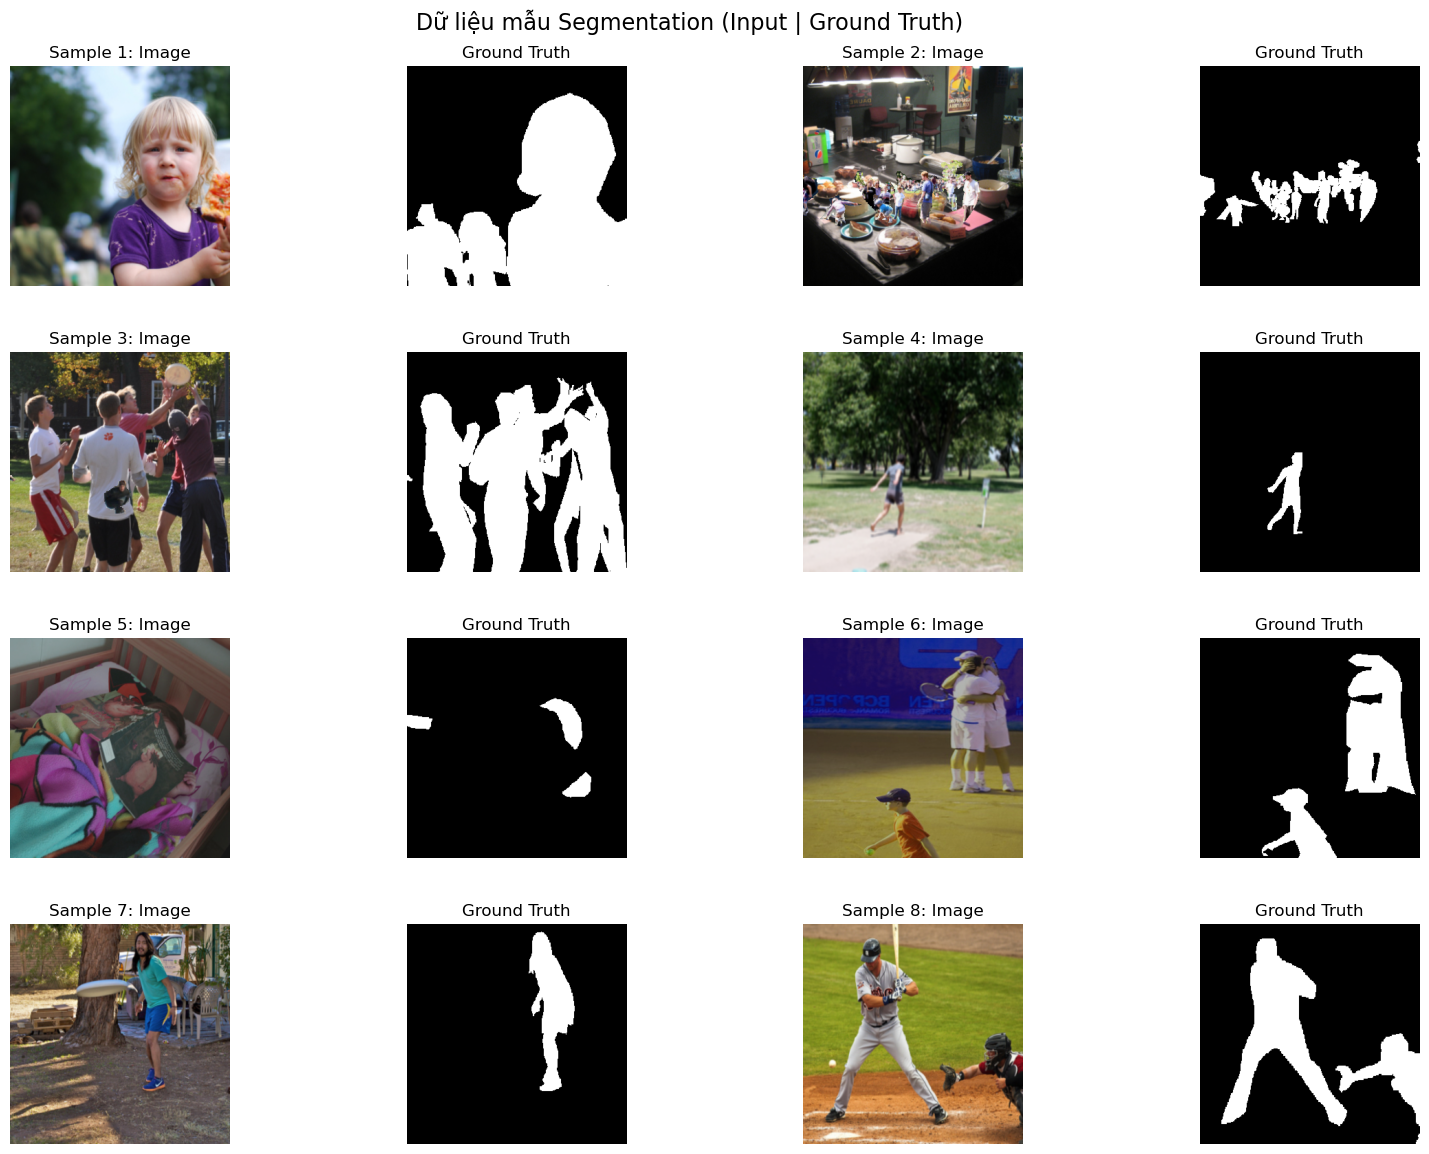

In [10]:
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=NUM_WORKERS,  
    pin_memory=True,
    prefetch_factor=2,       
    persistent_workers=True
)

visualize_datasets(train_loader)

In [11]:
print("Đang tải COCO Val Annotations...")
val_dataset = COCOPersonDataset(VAL_IMG_DIR, VAL_ANN_FILE, image_size=(320, 320), is_train = False)

Đang tải COCO Val Annotations...
loading annotations into memory...
Done (t=1.64s)
creating index...
index created!


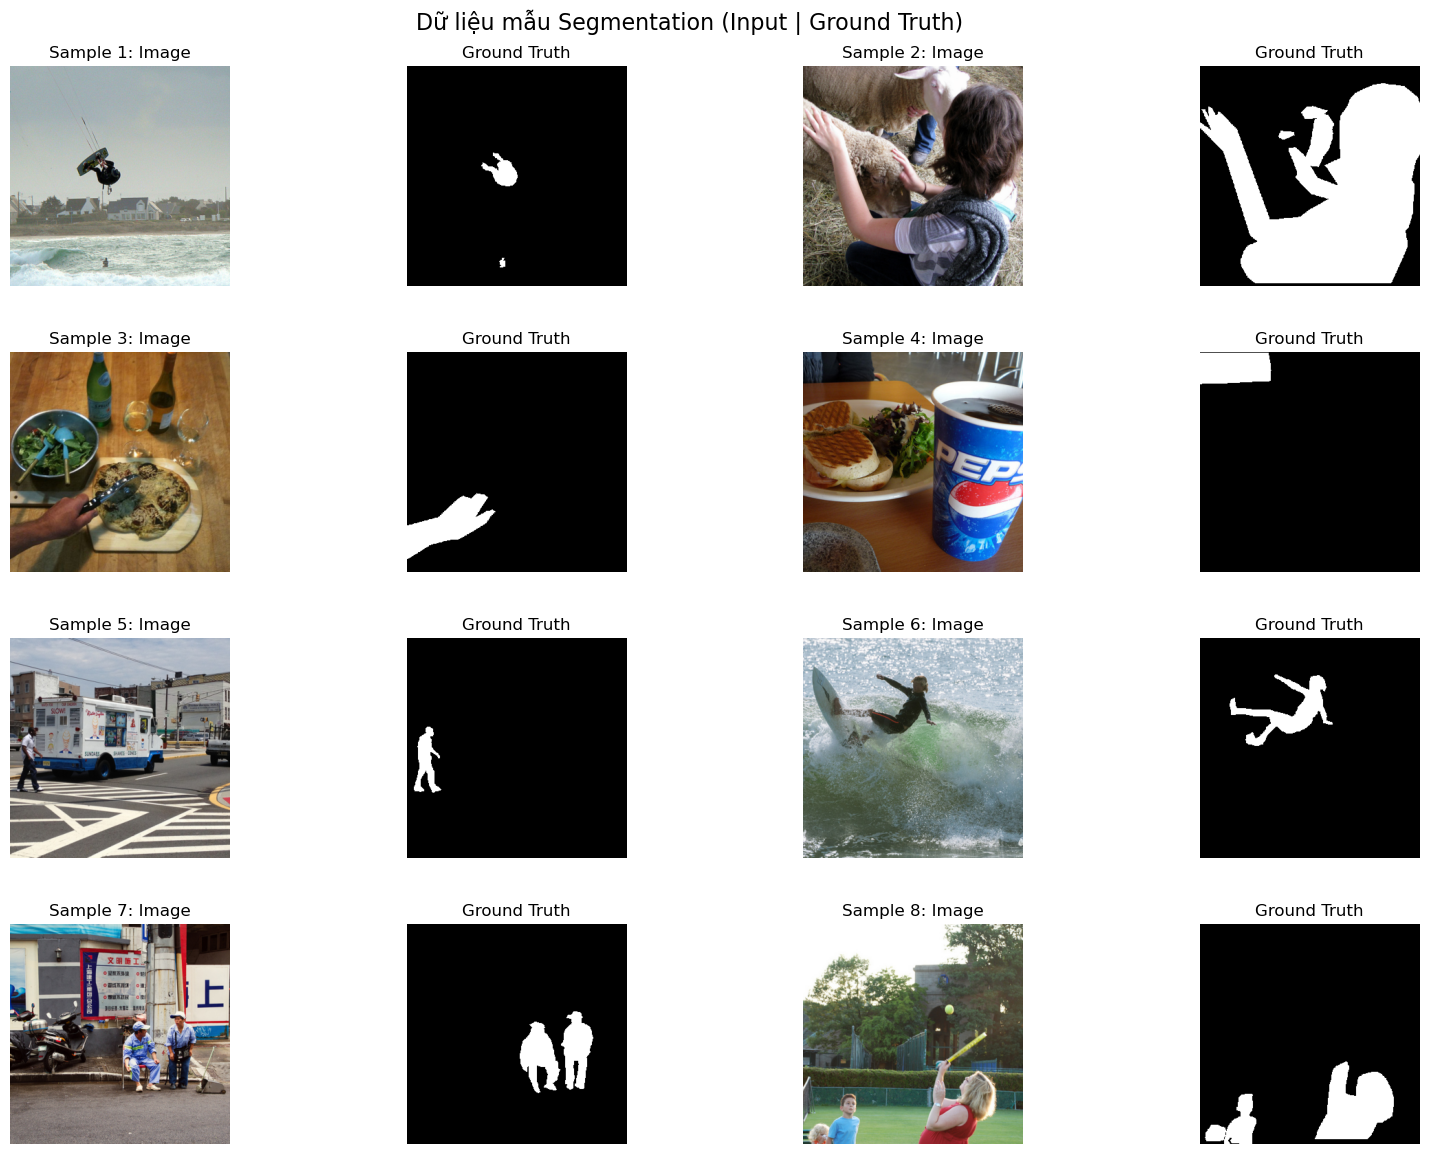

In [12]:
val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=NUM_WORKERS,  
    pin_memory=True,
    prefetch_factor=2,       
    persistent_workers=True
)
visualize_datasets(val_loader)

In [13]:
print(f"Tìm thấy {len(train_dataset)} ảnh Train và {len(val_dataset)} ảnh Val chứa người.")

Tìm thấy 64115 ảnh Train và 2693 ảnh Val chứa người.


In [14]:
torch.backends.cudnn.benchmark = True

In [15]:

model = model.to(device)
model = model.to(memory_format=torch.channels_last)
    
criterion = FocalDiceLoss(alpha=0.25, gamma=2.0, bce_weight=0.5)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCH, eta_min=1e-6
)
scaler = torch.cuda.amp.GradScaler(enabled=device.type == 'cuda')

best_val_loss = float('inf')

history = {
    'train_loss': [],
    'val_loss': [],
    'val_iou': [],
    'val_dice': [],
    'lr' : []
}

early_stop_counter = 0       

/tmp/ipykernel_210416/1242356613.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=device.type == 'cuda')


In [ ]:
for epoch in range(EPOCH):
    model.train()
    train_loss = 0.0
    
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCH} [Train]", unit="batch")
    for i, (images, masks) in enumerate(train_bar):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=device.type == 'cuda'):
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss = loss / accumulation_steps
            
        scaler.scale(loss).backward()
                
        if (i + 1) % accumulation_steps == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            
            
        
        actual_loss = loss.item() * accumulation_steps
        train_loss += actual_loss
        train_bar.set_postfix(loss=f"{actual_loss:.4f}")
    
    avg_train_loss = train_loss / len(train_loader)

    model.eval()
    val_loss = 0.0
    val_iou = 0.0
    val_dice = 0.0 
    
    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCH} [Val]", unit="batch", leave=False)
    with torch.no_grad():
        for images, masks in val_bar:
            images = images.to(device)
            masks = masks.to(device)

            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=device.type == 'cuda'):
                outputs = model(images)
                loss = criterion(outputs, masks)

            val_loss += loss.item()
            val_iou += calculate_iou(outputs, masks)
            val_dice += calculate_dice(outputs, masks) 

    avg_val_loss = val_loss / len(val_loader)
    avg_val_iou = val_iou / len(val_loader)
    avg_val_dice = val_dice / len(val_loader)
    
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['val_iou'].append(avg_val_iou)
    history['val_dice'].append(avg_val_dice)
    
    current_lr = optimizer.param_groups[0]['lr']
    history['lr'].append(current_lr)
    print(f"-> Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val IoU: {avg_val_iou:.4f} | Val Dice: {avg_val_dice:.4f} | LR: {current_lr:.2e}")
    

    checkpoint_state = {
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(), 
        'val_loss': avg_val_loss,
        'val_iou': avg_val_iou,
        'val_dice': avg_val_dice,
        'learning_rate' : current_lr,
        'history': history  
    }
    
    
    last_save = os.path.join(SAVE_MODEL_DIR, "last_unet_base.pth")
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        early_stop_counter = 0 
        
        best_save = os.path.join(SAVE_MODEL_DIR, "best_unet_base.pth")
        torch.save(checkpoint_state, best_save)
        print(f"Đã cập nhật mô hình tốt nhất tại: {best_save}\n")
    else:
        print("\n")
        if (epoch + 1) > min_epochs_before_stop:
            early_stop_counter += 1
            print(f"[Cảnh báo] Validation Loss không giảm. Lần {early_stop_counter}/{patience} (Early Stopping)")
            if early_stop_counter >= patience:
                print(f"==== EARLY STOPPING KÍCH HOẠT: Dừng huấn luyện sớm tại Epoch {epoch+1} ====")
                torch.save(checkpoint_state, last_save)
                break
    scheduler.step()
    torch.save(checkpoint_state, last_save)

Epoch 1/30 [Train]: 100%|██████████| 4008/4008 [09:02<00:00,  7.38batch/s, loss=0.3694]


-> Epoch 1 | Train Loss: 0.3247 | Val Loss: 0.3336 | Val IoU: 0.3489 | Val Dice: 0.4655 | LR: 1.00e-03
Đã cập nhật mô hình tốt nhất tại: ./models/unet_base/best_unet_base.pth



Epoch 2/30 [Train]: 100%|██████████| 4008/4008 [08:41<00:00,  7.69batch/s, loss=0.3795]


-> Epoch 2 | Train Loss: 0.2828 | Val Loss: 0.3116 | Val IoU: 0.3672 | Val Dice: 0.4850 | LR: 9.97e-04
Đã cập nhật mô hình tốt nhất tại: ./models/unet_base/best_unet_base.pth



Epoch 3/30 [Train]:  66%|██████▌   | 2652/4008 [05:46<02:57,  7.63batch/s, loss=0.2543]

In [ ]:
train_his_file = os.path.join(SAVE_MODEL_DIR, "training_history.json")
with open(train_his_file, "w") as f:
    json.dump(history, f, indent=4)
print(f"\nQuá trình huấn luyện hoàn tất! Đã xuất {train_his_file}.")

In [ ]:
def plot_training_history(history_source):
    """
    Hàm vẽ biểu đồ Loss, IoU, Dice Score và Learning Rate từ quá trình huấn luyện.
    """
    if isinstance(history_source, str) and os.path.exists(history_source):
        print(f"Đang đọc dữ liệu từ file: {history_source}")
        with open(history_source, "r") as f:
            history = json.load(f)
    elif isinstance(history_source, dict):
        history = history_source
    else:
        raise ValueError("Đầu vào phải là dictionary 'history' hoặc đường dẫn tới file JSON.")

    train_loss = history.get('train_loss', [])
    val_loss = history.get('val_loss', [])
    val_iou = history.get('val_iou', [])
    val_dice = history.get('val_dice', [])
    learning_rate = history.get('lr', [])
    
    epochs = range(1, len(train_loss) + 1)
    
    plt.figure(figsize=(16, 10))

    plt.subplot(2, 2, 1)
    plt.plot(epochs, train_loss, 'b-', label='Train Loss', linewidth=2)
    if val_loss:
        plt.plot(epochs, val_loss, 'r-', label='Validation Loss', linewidth=2)
    plt.title('Training and Validation Loss', fontsize=14)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)

    if learning_rate:
        plt.subplot(2, 2, 2)
        plt.plot(epochs, learning_rate, 'k-', label='Learning Rate', linewidth=2)
        plt.title('Learning Rate over Epochs', fontsize=14)
        plt.xlabel('Epoch', fontsize=12)
        plt.ylabel('Learning Rate', fontsize=12)
        plt.yscale('log') 
        plt.legend(fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.7)

    # Biểu đồ 3: Validation IoU
    if val_iou:
        plt.subplot(2, 2, 3)
        plt.plot(epochs, val_iou, 'g-', label='Validation IoU', linewidth=2)
        plt.title('Validation IoU', fontsize=14)
        plt.xlabel('Epoch', fontsize=12)
        plt.ylabel('IoU Score', fontsize=12)
        plt.legend(fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.7)

    # Biểu đồ 4: Validation Dice
    if val_dice:
        plt.subplot(2, 2, 4)
        plt.plot(epochs, val_dice, 'm-', label='Validation Dice', linewidth=2)
        plt.title('Validation Dice', fontsize=14)
        plt.xlabel('Epoch', fontsize=12)
        plt.ylabel('Dice Score', fontsize=12)
        plt.legend(fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

In [ ]:
plot_training_history(history)

In [ ]:
def visualize_predictions(model, dataloader, device, num_samples=8):
    """
    Trực quan hóa kết quả dự đoán của mô hình Segmentation.
    Mỗi sample hiển thị: Ảnh gốc | Ground Truth | Prediction.
    """
    model.eval()
    samples_shown = 0
    
    samples_per_row = 2
    nrows = math.ceil(num_samples / samples_per_row)
    ncols = samples_per_row * 3  
    
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 3.5 * nrows), squeeze=False)
    plt.subplots_adjust(wspace=0.1, hspace=0.3)
    
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )

    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device)
            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=device.type == 'cuda'):
                outputs = model(images)
            preds = torch.sigmoid(outputs) > 0.5
            
            images = images.cpu()
            masks = masks.cpu()
            preds = preds.cpu()

            for i in range(images.size(0)):
                if samples_shown >= num_samples:
                    break
                    
                row = samples_shown // samples_per_row
                col_offset = (samples_shown % samples_per_row) * 3
                
                img = inv_normalize(images[i]).permute(1, 2, 0).numpy()
                img = np.clip(img, 0, 1)
                
                gt_mask = masks[i].squeeze().numpy()
                pred_mask = preds[i].squeeze().numpy()

                ax_img = axes[row, col_offset]
                ax_img.imshow(img)
                ax_img.set_title(f"Sample {samples_shown+1}: Image")
                ax_img.axis('off')

                ax_gt = axes[row, col_offset + 1]
                ax_gt.imshow(gt_mask, cmap='gray')
                ax_gt.set_title("Ground Truth")
                ax_gt.axis('off')

                ax_pred = axes[row, col_offset + 2]
                ax_pred.imshow(pred_mask, cmap='gray')
                ax_pred.set_title("Prediction")
                ax_pred.axis('off')

                samples_shown += 1

            if samples_shown >= num_samples:
                break

    # Điều chỉnh khoảng cách của tiêu đề chính phụ thuộc vào số hàng
    plt.suptitle("Đánh giá mô hình Segmentation (Input | Ground Truth | Prediction)", fontsize=16, y=0.98 if nrows <= 2 else 0.92)
    plt.show()

In [ ]:
best_model_path = os.path.join(SAVE_MODEL_DIR, "best_unet_base.pth")
best_checkpoint = torch.load(best_model_path) 
model.load_state_dict(best_checkpoint['model_state_dict'])

print("\nĐang trực quan hóa kết quả...")
visualize_predictions(model, val_loader, device, num_samples=16)

In [ ]:
def apply_color_mask(image, mask, color=(0.0, 1.0, 0.0), alpha=0.5):
    """
    Phủ một lớp màu bán trong suốt lên vùng có mask.
    - image: mảng numpy ảnh gốc (H, W, 3), giá trị [0, 1]
    - mask: mảng numpy nhị phân (H, W), giá trị 0 hoặc 1
    - color: tuple màu RGB (mặc định Xanh lá)
    - alpha: độ trong suốt (0.0 -> 1.0)
    """
    colored_image = image.copy()
    for c in range(3):
        colored_image[:, :, c] = np.where(
            mask > 0,
            image[:, :, c] * (1 - alpha) + alpha * color[c],
            image[:, :, c]
        )
    return np.clip(colored_image, 0, 1)

def visualize_predictions_colored(model, dataloader, device, num_samples=8):
    """
    Trực quan hóa kết quả có phủ màu (Color Overlay).
    """
    model.eval()
    samples_shown = 0
    
    # 1. Tính toán kích thước lưới động
    samples_per_row = 2
    nrows = math.ceil(num_samples / samples_per_row)
    ncols = samples_per_row * 3  # Mỗi sample chiếm 3 cột
    
    # 2. Khởi tạo subplots với squeeze=False để an toàn với mảng 2D
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 3.5 * nrows), squeeze=False)
    plt.subplots_adjust(wspace=0.1, hspace=0.3)
    
    inv_normalize = transforms.Normalize(
        mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
        std=[1/0.229, 1/0.224, 1/0.225]
    )

    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device)

            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=device.type == 'cuda'):
                outputs = model(images)
            
            preds = torch.sigmoid(outputs) > 0.5

            images = images.cpu()
            masks = masks.cpu()
            preds = preds.cpu()

            for i in range(images.size(0)):
                if samples_shown >= num_samples:
                    break
                
                # 3. Tính toán vị trí hiển thị dựa trên lưới động
                row = samples_shown // samples_per_row
                col_offset = (samples_shown % samples_per_row) * 3

                img = inv_normalize(images[i]).permute(1, 2, 0).numpy()
                img = np.clip(img, 0, 1)

                gt_mask = masks[i].squeeze().numpy()
                pred_mask = preds[i].squeeze().numpy()

                gt_overlay = apply_color_mask(img, gt_mask, color=(0.0, 1.0, 0.0), alpha=0.5)
                pred_overlay = apply_color_mask(img, pred_mask, color=(1.0, 0.0, 0.0), alpha=0.5)

                ax_img = axes[row, col_offset]
                ax_img.imshow(img)
                ax_img.set_title(f"Sample {samples_shown+1}")
                ax_img.axis('off')

                ax_gt = axes[row, col_offset + 1]
                ax_gt.imshow(gt_overlay)
                ax_gt.set_title("Truth (Green)")
                ax_gt.axis('off')

                ax_pred = axes[row, col_offset + 2]
                ax_pred.imshow(pred_overlay)
                ax_pred.set_title("Pred (Red)")
                ax_pred.axis('off')

                samples_shown += 1

            if samples_shown >= num_samples:
                break
            
    title_y = 0.98 if nrows <= 2 else 0.92
    plt.suptitle("Đánh giá mô hình Segmentation (Overlay Màu)", fontsize=18, y=title_y, fontweight='bold')
    plt.show()

In [ ]:
print("\nĐang trực quan hóa kết quả...")
visualize_predictions_colored(model, val_loader, device, num_samples=8)

In [ ]:
print("\nĐang trực quan hóa kết quả...")
visualize_predictions_colored(model, train_loader, device, num_samples=8)